In [3]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
import scienceplots
from os.path import exists
import seaborn as sns

import sys
sys.path.append("../")
from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

## Quick evidence check

In [4]:
def f(simname, catalogue):
    fname = paths.flow_validation(
        fdir, simname, catalogue=catalogue, inference_method="mike",
        sample_alpha=True, sample_beta=None, sample_mag_dipole=True, dust_model=None,
        zcmb_max=0.05)
    
    logZ_dipole = -get_gof("neg_lnZ_harmonic", fname) / np.log(10)
    print(f"With dipole {logZ_dipole:.3f}")

    fname = paths.flow_validation(
        fdir, simname, catalogue=catalogue, inference_method="mike",
        sample_alpha=True, sample_beta=None, sample_mag_dipole=False, dust_model=None,
        zcmb_max=0.05)
    
    logZ_nodipole = -get_gof("neg_lnZ_harmonic", fname) / np.log(10)
    print(f"Without dipole {logZ_nodipole:.3f}")

    
    dlogZ = logZ_dipole - logZ_nodipole
    print(f"\nlogZ in favour of dipole = {dlogZ}")



In [22]:
f("manticore_2MPP_MULTIBIN_N256_DES_V2", "CF4_TFR_w1")

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_manticore_2MPP_MULTIBIN_N256_DES_V2_CF4_TFR_w1_mike_zcmb_max_0.05_sample_alpha_sample_mag_dipole.hdf5
Last modified: 12/02/2025 08:32:15
With dipole -10993.322
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_manticore_2MPP_MULTIBIN_N256_DES_V2_CF4_TFR_w1_mike_zcmb_max_0.05_sample_alpha.hdf5
Last modified: 12/02/2025 08:26:58
Without dipole -10985.410

logZ in favour of dipole = -7.911454360764765


## Quick checks

In [37]:
# manticore_2MPP_MULTIBIN_N256_DES_V2

fname = paths.flow_validation(
    fdir, "Carrick2015", catalogue="CF4_TFR_w1", inference_method="mike",
    sample_alpha=True, sample_beta=None, sample_mag_dipole=True, dust_model=None,
    zcmb_max=0.05)

fname
print("logZ = ", -get_gof("neg_lnZ_harmonic", fname) / np.log(10))
samples = get_some_samples(fname, ["aTFR_dipole"])

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_mike_zcmb_max_0.05_sample_alpha_sample_mag_dipole.hdf5
Last modified: 12/02/2025 05:26:40
logZ =  -11271.550900374094


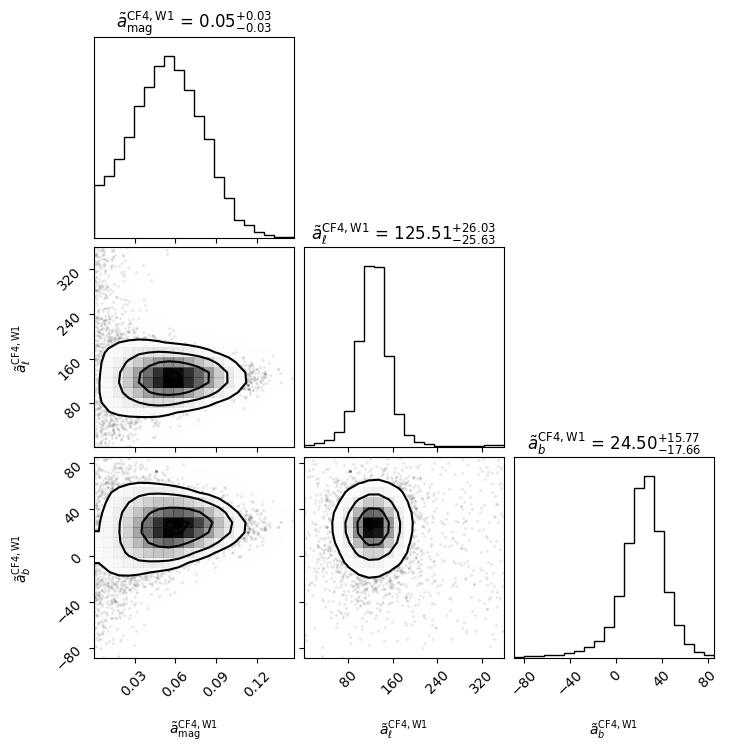

In [38]:
corner_samples, labels, keys = samples_for_corner(samples)

fig = corner(corner_samples, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)
fig.savefig("../../../plots/corner.png", dpi=250)
fig.show()